## DFT vs. MLIPs Energy Comparison Pipeline

This notebook compares MLIP-predicted energies and forces against DFT reference calculations. For each frame in a DFT trajectory, the MLIP takes the DFT-computed structure (atomic positions, cell) as input and performs a single-point evaluation, predicting E and F(r) for that fixed, pre-relaxed geometry. 

The question this tries to answer is: *Given the same structure DFT saw, how close are the MLIP energies and forces?*

Comparison plots are then generated for raw potential energy, relative energy along the trajectory, and adsorption energy (E_ads = E_tot − E_slab − E_gas).

Currently, models used are MACE, MatterSim, and UMA (each run by a script in `model-scripts`).

Note: Although the MLIPs models below are not trained on magnetic field data, magnetically-perturbed DFT data was given and used when constructing the pipeline.


**Directory Setup** \
To run this notebook, make sure your directory structure mimics this:

#### 0. Configuration

In [1]:
import numpy as np
from ase.io import iread, read, write

In [3]:
# construct data structure used to hold user input

# builds dict describing 1 DFT run (adsorbate system, slab, gas reference).
# the inner path() helper function resolves file paths:
#   - if a full path is given (contains '/'), use it directly
#   - otherwise, construct the standard path under dft-data/
# this lets you override individual paths without changing the defaults.

def make_run(label, bext, ads=None, slab=None, gas=None):
    def path(snippet, default):
        if snippet and '/' in snippet:
            return snippet  # fully specified path, use as-is
        name = snippet or label + default
        return f"dft-data/{name}_BEXT{bext}/vasprun.xml"
    
    run_id = f"{label}_BEXT{bext}"
    
    return {
        "label": label,
        "bext":  bext,
        "run_id": run_id,
        "ads":   path(ads,  "diss2"),
        "slab":  path(slab, "surf"),
        "gas":   path(gas,  "mag2"),
    }

def make_model(name, python_bin, script_path):
    return {
        "name":       name,
        "python_bin": python_bin,
        "script":     script_path
    }

In [12]:
# ========================================
# USER INPUT HERE - edit add new DFT runs
# ========================================

# do you want to re-run model relaxations? (note: takes time!)
RUN_RELAXATIONS = True  # set to True when ready

# do you want to read in new DFT data and write energies?
WRTIE_DFT_DATA = True  # set to True to overwrite files in script-data/

# RUNS: one entry per DFT run. make_run(label, bext) where label is typically
# the adsorbate name; pass slab= or gas= for a clean slab or unattached adsorbate
RUNS = ([make_run("NH3", b) for b in [0.1, 0.24, 0.37, 0.5]] +
        [make_run("H2", b, slab="NH3surf", gas="dft-data/H2_gas/vasprun.xml") for b in [0.1, 0.24, 0.37, 0.5]]
)

In [39]:
# ======================================
# USER INPUT HERE - edit add new models
# ======================================

import subprocess

def conda_python(env_name):
    # resolve env name (eg. 'mlip-mace') to its python binary for the machine this notebook
    # is running on
    out = subprocess.run(['conda', 'env', 'list', '--json'], capture_output=True, text=True)
    import json
    envs = json.loads(out.stdout)['envs']
    for p in envs:
        if p.rstrip('/').endswith(env_name):
            return f"{p}/bin/python"
    raise RuntimeError(f"conda env '{env_name}' not found")

# MODELS: each entry is (display name, path to that model's python interpreter, runner script).
# each MLIP lives in its own conda env to avoid dependency conflicts.

MODELS = [
    {'name': 'MACE',      'python_bin': conda_python('mlip-mace'),      'script': 'model-scripts/run_mace.py'},
    {'name': 'MatterSim', 'python_bin': conda_python('mlip-mattersim'), 'script': 'model-scripts/run_mattersim.py'},
    {'name': 'UMA',       'python_bin': conda_python('mlip-uma'),       'script': 'model-scripts/run_uma.py'},
]

#### 1. DFT data ingestion

In [40]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    return frames

# for single-structure files (slab reference, gas reference)
def load_frame(path):
    frame = read(path)
    return frame

In [43]:
# construct path for dft/model results 

# used by DFT-write step and model-run step
# and to (re)populate RUNS with paths when re-running with flags off

SCRIPT_DATA_ROOT = "model-scripts/script-data"

def run_paths(run, root=SCRIPT_DATA_ROOT):
    rid = run['run_id']
    return {
        'xyz_ads':  f"{root}/input_ads_{rid}.xyz",
        'xyz_slab': f"{root}/input_slab_{rid}.xyz",
        'xyz_gas':  f"{root}/input_gas_{rid}.xyz",
        'results':  {m['name'].lower(): f"{root}/results_{m['name'].lower()}_{rid}.npz" for m in MODELS},
    }

In [44]:
# run this to read in new DFT data

# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later

if WRTIE_DFT_DATA:
    from pathlib import Path

    # loop through and delete old files in model-scripts/script-data/
    for file in Path(SCRIPT_DATA_ROOT).glob("*"):
        if file.is_file():
            file.unlink()  # delete file

    # repopulate script-data/ with new DFT data
    for run in RUNS:
        paths = run_paths(run)
        run['xyz_ads']  = paths['xyz_ads']
        run['xyz_slab'] = paths['xyz_slab']
        run['xyz_gas']  = paths['xyz_gas']

        write(run['xyz_ads'],  load_frames(run['ads']))
        write(run['xyz_slab'], load_frame(run['slab']))
        write(run['xyz_gas'],  load_frame(run['gas']))
else:
    print("cell skipped!")

#### 2. run MLIPs (MACE, MatterSim, UMA)

In [45]:
if RUN_RELAXATIONS:
    # find device to run model on
    import torch

    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        device = "mps"   # for apple silicon gpus (M-series chips)
    elif torch.cuda.is_available():
        device = "cuda"  # for gpus w/ nvidia cuda backend
    else:
        device = "cpu"   # default 
    
    print(f"{device} found!")
else:
    print("cell skipped!")

mps found!


In [47]:
# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

import os

if RUN_RELAXATIONS:
    env = os.environ.copy()
    env['MPLBACKEND'] = "Agg"

    for model in MODELS:
        for run in RUNS:
            out = run_paths(run)['results'][model['name'].lower()]
            r = subprocess.run(
                [model['python_bin'], model['script'],
                run['xyz_ads'], run['xyz_slab'], run['xyz_gas'], out],
                capture_output=True, text=True, env=env
            )
            if r.returncode != 0:
                print(f"-- [{run['run_id']}] ({model['name']}): failed")
                if r.stdout: print(r.stdout)
                if r.stderr: print(r.stderr)
                print("Return code:", r.returncode)
            else:
                print(f"-- [{run['run_id']}] ({model['name']}): success")
else:
    print("cell skipped!")

-- [NH3_BEXT0.1] (MACE): success
-- [NH3_BEXT0.24] (MACE): success
-- [NH3_BEXT0.37] (MACE): success
-- [NH3_BEXT0.5] (MACE): success
-- [H2_BEXT0.1] (MACE): success
-- [H2_BEXT0.24] (MACE): success
-- [H2_BEXT0.37] (MACE): success
-- [H2_BEXT0.5] (MACE): success
-- [NH3_BEXT0.1] (MatterSim): success
-- [NH3_BEXT0.24] (MatterSim): success
-- [NH3_BEXT0.37] (MatterSim): success
-- [NH3_BEXT0.5] (MatterSim): success
-- [H2_BEXT0.1] (MatterSim): success
-- [H2_BEXT0.24] (MatterSim): success
-- [H2_BEXT0.37] (MatterSim): success
-- [H2_BEXT0.5] (MatterSim): success
-- [NH3_BEXT0.1] (UMA): success
-- [NH3_BEXT0.24] (UMA): success
-- [NH3_BEXT0.37] (UMA): success
-- [NH3_BEXT0.5] (UMA): success
-- [H2_BEXT0.1] (UMA): success
-- [H2_BEXT0.24] (UMA): success
-- [H2_BEXT0.37] (UMA): success
-- [H2_BEXT0.5] (UMA): success


In [48]:
# repopulates each run dict with data stored in the .xyz/.npz files
# without having to re-run any models 

for run in RUNS:
    run.update(run_paths(run))

#### 3. plot results (model E<sub>slab+ads</sub> vs. DFT E<sub>slab+ads</sub>)

In [65]:
import matplotlib.pyplot as plt
import math
from scipy.stats import pearsonr

col_w = 5

# group runs by label to preserve order
labels = list(dict.fromkeys(r['label'] for r in RUNS))
runs_by_label = {lbl: [r for r in RUNS if r['label'] == lbl] for lbl in labels}

In [62]:
# read DFT energies from saved XYZ files into each run dict
# slab_energy and gas_energy are single reference values used to compute E_ads later

for run in RUNS:
    frames = read(run['xyz_ads'], index=":")
    run['dft'] = {
        "energies":    np.array([a.get_potential_energy() for a in frames]),
        "slab_energy": read(run['xyz_slab']).get_potential_energy(),
        "gas_energy":  read(run['xyz_gas']).get_potential_energy(),
    }

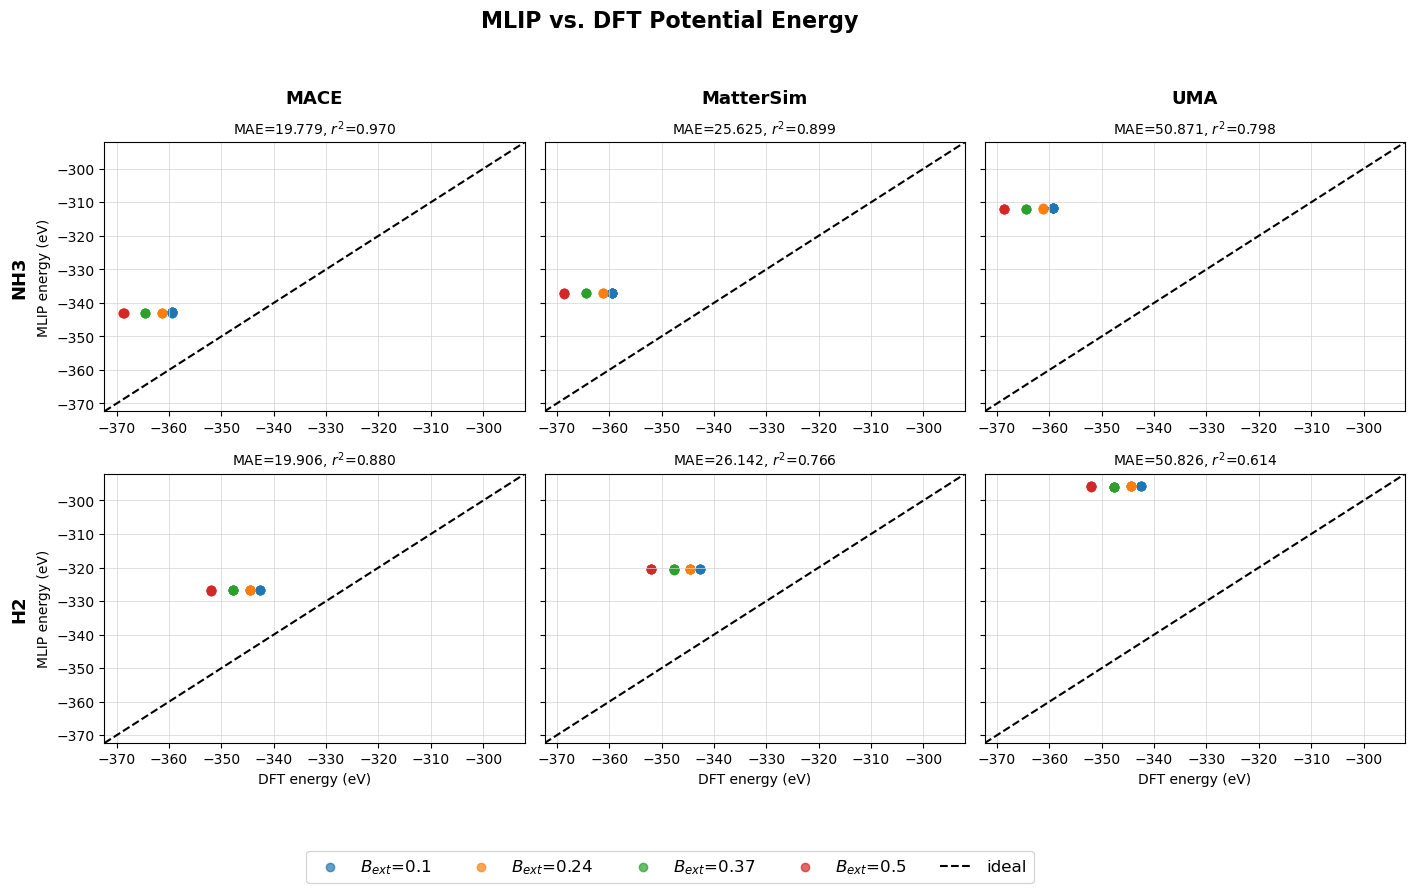

In [64]:
# --- fig 1a: parity plot w/ total energies, adsorbates x models grid ---
n_ads = len(labels)
n_models = len(MODELS)
fig, axes = plt.subplots(n_ads, n_models, figsize=(n_models*col_w, n_ads*4.5), dpi=100)
axes = np.atleast_2d(axes)
fig.suptitle("MLIP vs. DFT Potential Energy", fontsize=16, fontweight='semibold')

# global axis limits across everything, so all subplots share scale
all_e = [e for run in RUNS
            for model in MODELS
            for e in [run['dft']['energies'],
                        np.load(run['results'][model['name'].lower()])['mlip_energies']]]
gmin = min(e.min() for e in all_e)
gmax = max(e.max() for e in all_e)
pad  = (gmax - gmin) * 0.05
gmin -= pad; gmax += pad

bext_vals = sorted({run['bext'] for run in RUNS})
bext_colors = {b: plt.cm.tab10(i) for i, b in enumerate(bext_vals)}

for row, lbl in enumerate(labels):
    label_runs = runs_by_label[lbl]
    for col, model in enumerate(MODELS):
        name = model['name']
        key = name.lower()
        ax = axes[row, col]

        dft_all, mlip_all = [], []
        for run in label_runs:
            dft_e = run['dft']['energies']
            mlip_e = np.load(run['results'][key])['mlip_energies']
            dft_all.append(dft_e)
            mlip_all.append(mlip_e)
            ax.scatter(dft_e, mlip_e, alpha=0.7, color=bext_colors[run['bext']],
                       label=f"$B_{{ext}}$={run['bext']}")

        dft_all = np.concatenate(dft_all)
        mlip_all = np.concatenate(mlip_all)
        mae = np.mean(np.abs(mlip_all - dft_all))
        r = pearsonr(dft_all, mlip_all).statistic ** 2  # pearson r^2 -- insensitive to energy offsets

        ax.plot([gmin, gmax], [gmin, gmax], 'k--', label="ideal")
        ax.set_xlim(gmin, gmax); ax.set_ylim(gmin, gmax)
        ax.grid(color='lightgrey', linewidth=0.5)
        ax.set_title(f"MAE={mae:.3f}, $r^2$={r:.3f}", fontsize=10)

        # column headers: model name, once per column on the top row
        if row == 0:
            ax.annotate(name, xy=(0.5, 1), xytext=(0, 28),
                         xycoords='axes fraction', textcoords='offset points',
                         ha='center', va='baseline', fontsize=13, fontweight='bold')

        # row labels: adsorbate name, once per row on the left column
        if col == 0:
            ax.annotate(lbl, xy=(0, 0.5), xytext=(-55, 0),
                         xycoords='axes fraction', textcoords='offset points',
                         ha='right', va='center', fontsize=13, fontweight='bold',
                         rotation=90)
            ax.set_ylabel("MLIP energy (eV)")
        else:
            ax.set_yticklabels([])

        if row == n_ads - 1:
            ax.set_xlabel("DFT energy (eV)")

handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=len(bext_vals)+1,
            bbox_to_anchor=(0.5, 0.0), fontsize=12)
plt.tight_layout(rect=[0.05, 0.1, 1, 0.95])
plt.show()

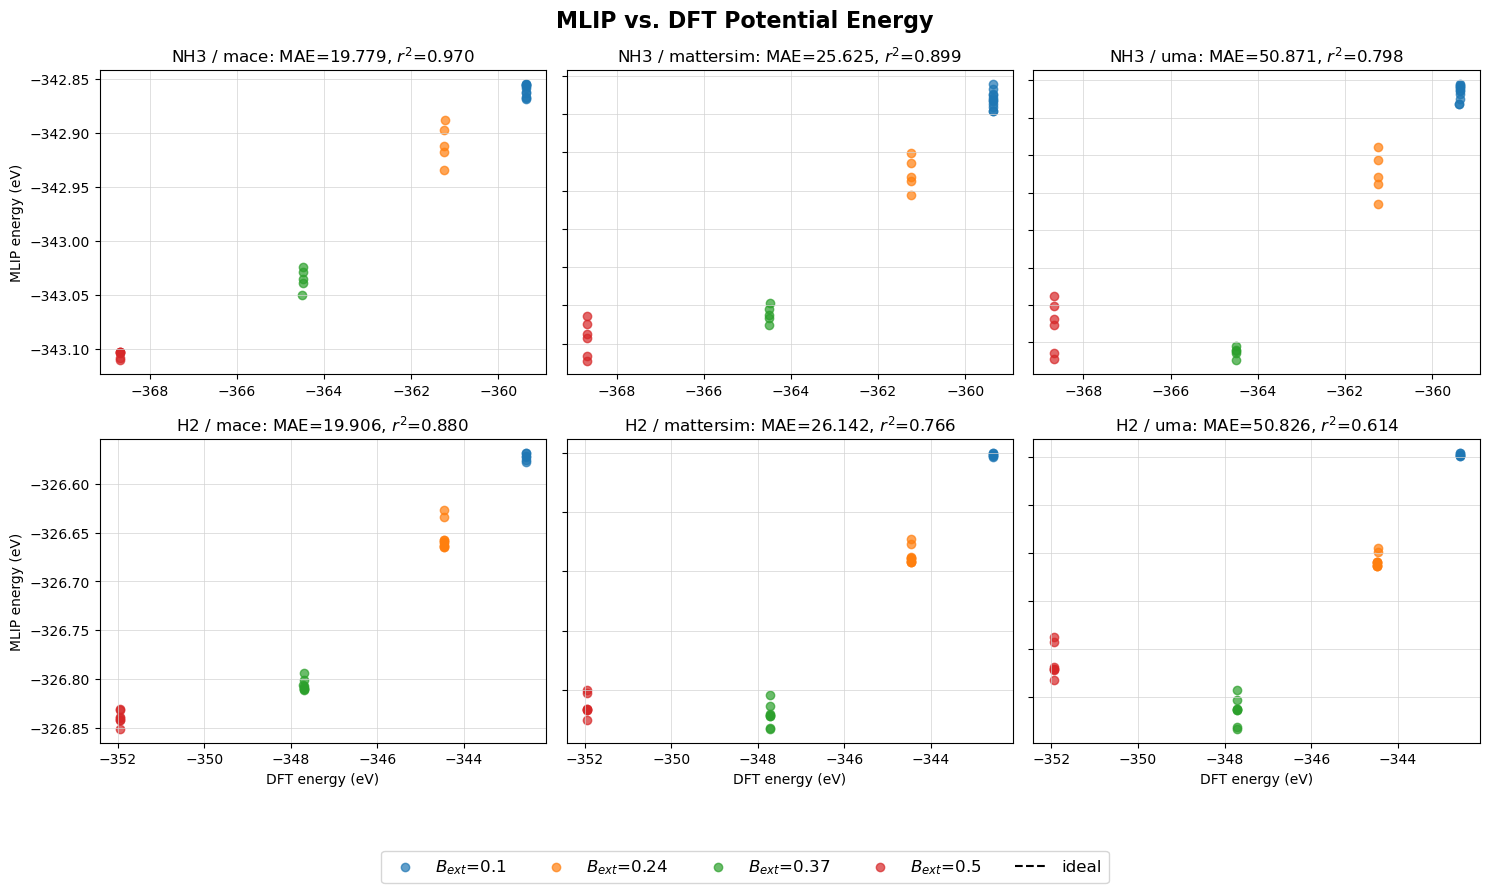

In [ ]:
# --- fig 1b: parity plot w/ total energies, adsorbates x models grid ---
n_ads = len(labels)
n_models = len(MODELS)
fig, axes = plt.subplots(n_ads, n_models, figsize=(n_models*col_w, n_ads*4.5), dpi=100)
axes = np.atleast_2d(axes)
fig.suptitle("MLIP vs. DFT Potential Energy", fontsize=16, fontweight='semibold')

bext_vals = sorted({run['bext'] for run in RUNS})
bext_colors = {b: plt.cm.tab10(i) for i, b in enumerate(bext_vals)}

for row, lbl in enumerate(labels):
    label_runs = runs_by_label[lbl]
    for col, model in enumerate(MODELS):
        name = model['name']
        ax = axes[row, col]

        dft_all, mlip_all = [], []
        for run in label_runs:
            dft_e = run['dft']['energies']
            mlip_e = np.load(run['results'][name])['mlip_energies']
            dft_all.append(dft_e)
            mlip_all.append(mlip_e)
            ax.scatter(dft_e, mlip_e, alpha=0.7, color=bext_colors[run['bext']],
                       label=f"$B_{{ext}}$={run['bext']}")

        dft_all = np.concatenate(dft_all)
        mlip_all = np.concatenate(mlip_all)
        mae = np.mean(np.abs(mlip_all - dft_all))
        r = pearsonr(dft_all, mlip_all).statistic ** 2  # pearson r^2 -- insensitive to energy offsets

        # independent x/y limits, padded to the data -- not forced square,
        # so an offset (e.g. UMA's RPBE/PBE shift) doesn't blow up the zoom
        xpad = (dft_all.max() - dft_all.min()) * 0.05
        ypad = (mlip_all.max() - mlip_all.min()) * 0.05
        xmin, xmax = dft_all.min() - xpad, dft_all.max() + xpad
        ymin, ymax = mlip_all.min() - ypad, mlip_all.max() + ypad

        # y=x line spans the union of both ranges, so it shows up even if
        # it falls outside the zoomed data window
        lo = min(xmin, ymin)
        hi = max(xmax, ymax)
        ax.plot([lo, hi], [lo, hi], 'k--', label="ideal")

        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
        ax.grid(color='lightgrey', linewidth=0.5)
        ax.set_title(f"{lbl} / {name}: MAE={mae:.3f}, $r^2$={r:.3f}")

        if row == n_ads - 1:
            ax.set_xlabel("DFT energy (eV)")
        if col == 0:
            ax.set_ylabel("MLIP energy (eV)")
        else:
            ax.set_yticklabels([])

handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=len(bext_vals)+1,
            bbox_to_anchor=(0.5, 0.0), fontsize=12)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

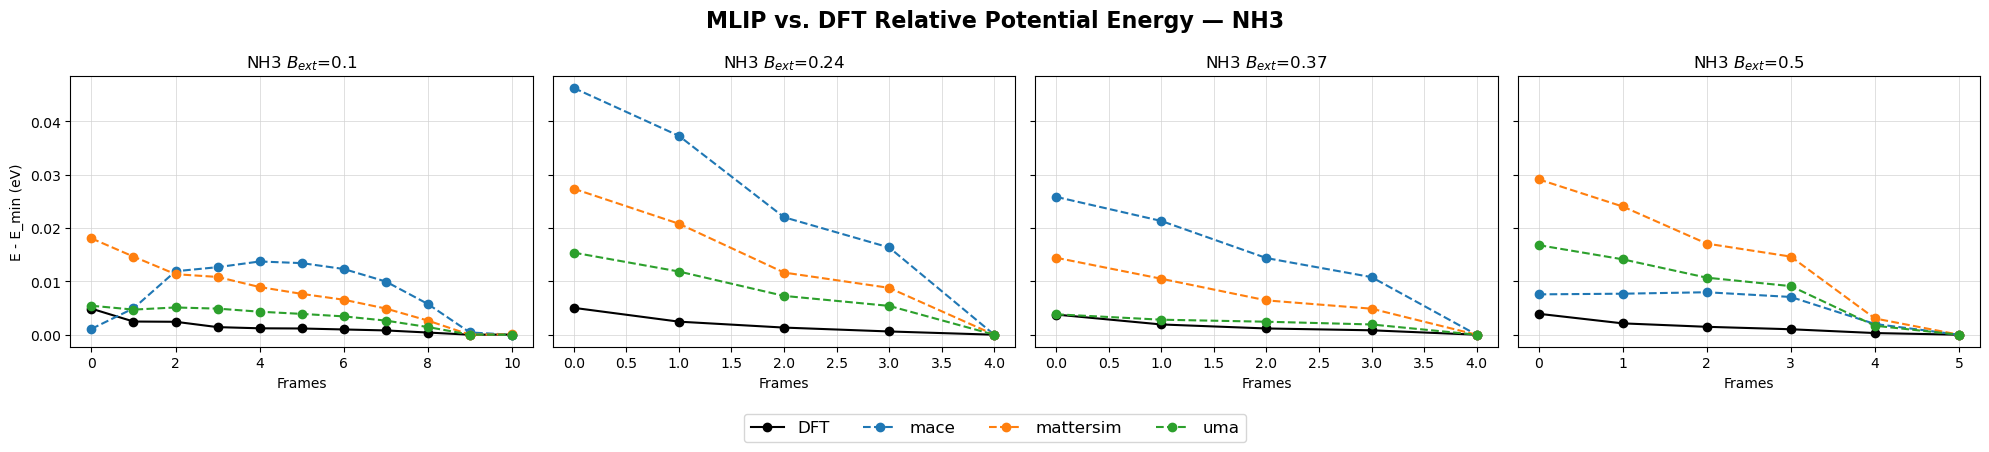

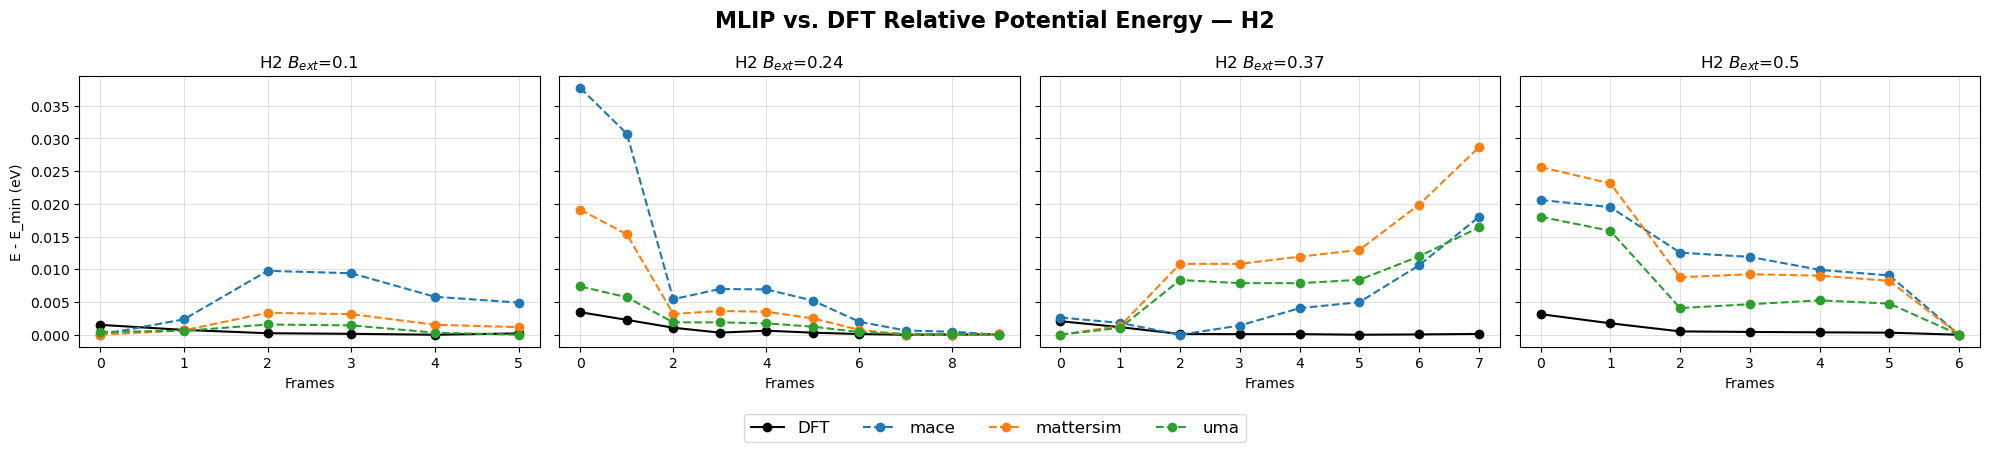

In [36]:
# --- Figure(s) 2: Relative Energy ---
for lbl, label_runs in runs_by_label.items():
    ncols = min(len(label_runs), 4)
    nrows = math.ceil(len(label_runs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4.5), dpi=100)
    axes = np.array(axes).flatten()
    fig.suptitle(f"MLIP vs. DFT Relative Potential Energy — {lbl}", fontsize=16, fontweight='semibold')

    all_rel = []
    for run in label_runs:
        dft_e = run['dft']['energies']
        all_rel.append(dft_e - dft_e.min())
        for model in MODELS:
            mlip_e = np.load(run['results'][model['name']])['mlip_energies']
            all_rel.append(mlip_e - mlip_e.min())
    rel_min = min(e.min() for e in all_rel)
    rel_max = max(e.max() for e in all_rel)
    pad = (rel_max - rel_min) * 0.05
    rel_min -= pad; rel_max += pad

    for i, run in enumerate(label_runs):
        ax = axes[i]
        dft_e = run['dft']['energies']
        dft_rel = dft_e - dft_e.min()
        frames = range(len(dft_e))
        ax.plot(frames, dft_rel, 'k-o', label="DFT")
        for j, model in enumerate(MODELS):
            name = model['name']
            color = plt.cm.tab10(j)
            mlip_e = np.load(run['results'][name])['mlip_energies']
            ax.plot(frames, mlip_e - mlip_e.min(), '--o', color=color, label=name)
        ax.set_ylim(rel_min, rel_max)
        ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
        ax.set_xlabel("Frames")
        ax.grid(color='lightgrey', linewidth=0.5)
        if i % ncols == 0:
            ax.set_ylabel("E - E_min (eV)")
        else:
            ax.set_yticklabels([])
    for ax in axes[len(label_runs):]:
        ax.set_visible(False)
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', ncol=len(MODELS)+1,
                bbox_to_anchor=(0.5, 0.0), fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

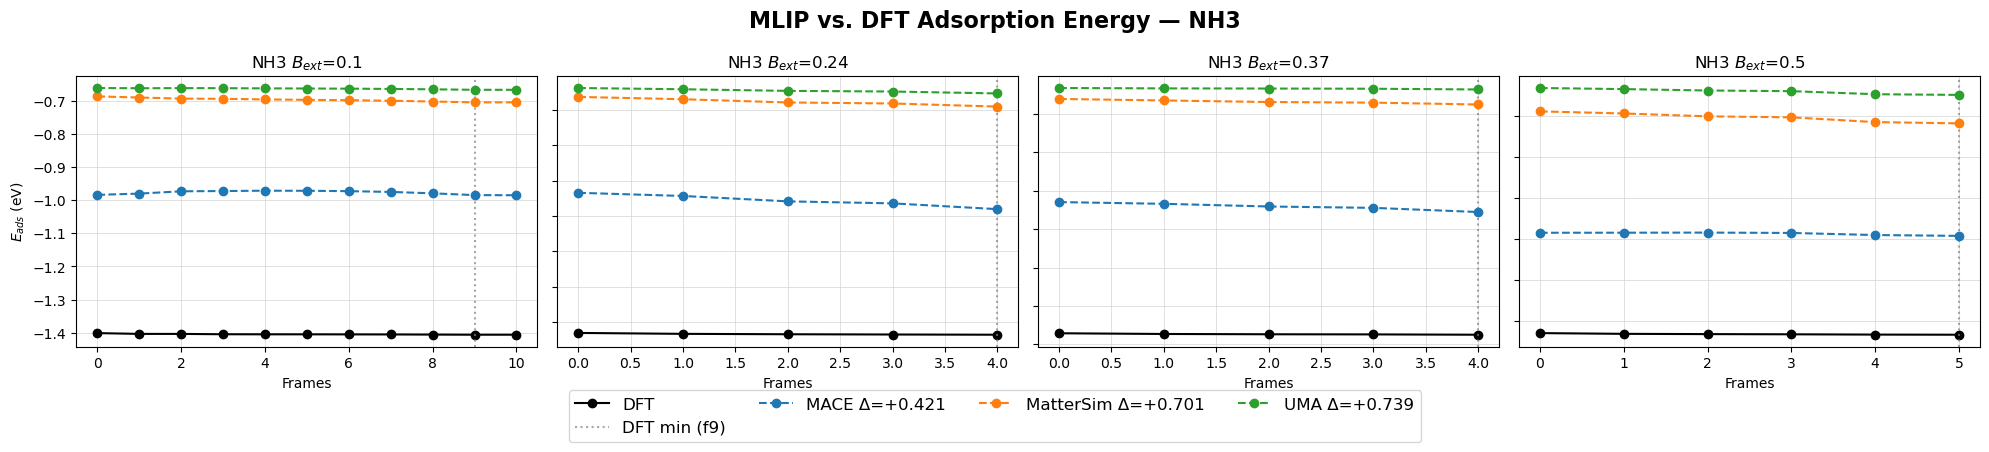

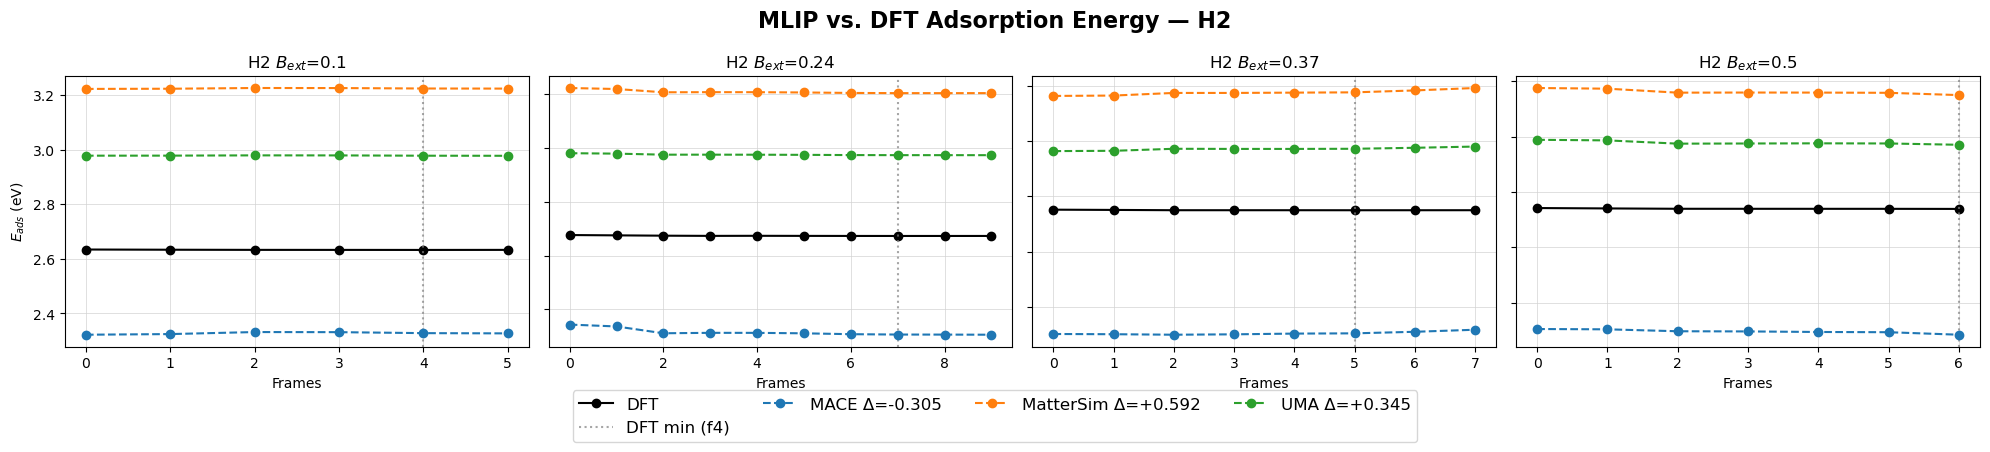

In [ ]:
# --- Figure(s) 3: Adsorption Energy ---
for lbl, label_runs in runs_by_label.items():
    ncols = min(len(label_runs), 4)
    nrows = math.ceil(len(label_runs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4.5), dpi=100)
    axes = np.array(axes).flatten()
    fig.suptitle(f"MLIP vs. DFT Adsorption Energy — {lbl}", fontsize=16, fontweight='semibold')

    for i, run in enumerate(label_runs):
        ax = axes[i]
        dft_e   = run['dft']['energies']
        dft_ads = dft_e - run['dft']['slab_energy'] - run['dft']['gas_energy']
        dft_min = np.argmin(dft_ads)
        frames  = range(len(dft_e))
        ax.plot(frames, dft_ads, 'k-o', label="DFT")
        ax.axvline(dft_min, color='gray', linestyle=':', alpha=0.7, label=f"DFT min (f{dft_min})")
        for j, (name, *_) in enumerate(MODELS):
            color    = plt.cm.tab10(j)
            res      = np.load(run['results'][name])
            mlip_ads = res['mlip_energies'] - res['slab_energy'] - res['gas_energy']
            err      = mlip_ads[dft_min] - dft_ads[dft_min]
            ax.plot(frames, mlip_ads, '--o', color=color, label=f"{name} Δ={err:+.3f}")
        ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
        ax.set_xlabel("Frames")
        ax.grid(color='lightgrey', linewidth=0.5)
        if i % ncols == 0:
            ax.set_ylabel("$E_{ads}$ (eV)")
        else:
            ax.set_yticklabels([])

    for ax in axes[len(label_runs):]:
        ax.set_visible(False)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', ncol=len(MODELS)+1,
                bbox_to_anchor=(0.5, 0.0), fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()